# Dataset Description

## **The dataset has been Netduced by the below-mentioned researches:**
- E. C. P. Neto, S. Dadkhah, R. Ferreira, A. Zohourian, R. Lu, A. A. Ghorbani. "CICIoT2023: A real-time dataset and benchmark for large-scale attacks in IoT environment," Sensor (2023) – (submitted to Journal of Sensors).
- The present data contains different kinds of IoT intrusions. The categories of the IoT intrusions enlisted in the data are as follows:
- DDoS
- Brute Force
- Spoofing
- DoS
- Recon
- Web-based
- Mirai

There are several subcategories are present in the data for each kind of intrusion types in the IoT. The dataset contains 1191264 instances of network for intrusions and 47 features of each of the intrusions. The dataset can be used to prepare the predictive model through which different kind of intrusive attacks can be detected. The data is also suitable for designing the IDS system.

# Abbreviations

```markdown

|Column Name	| Abbreviation	| Explanation |
|---------------|---------------|-------------|
|flow_duration	|FD	            |Total duration of the flow (in seconds) between two network endpoints.|
|Header_Length	|HL	|The total length of the packet headers in bytes.|
|Protocol Type	|PT	|Indicates the type of protocol used in the network traffic (e.g., TCP, UDP, ICMP).|
|Duration	|D |	The duration for which the network connection was active.|
|Rate	|R	|The rate of data transmission (e.g., packets per second or bytes per second).|
|Srate	|SR|	Source rate; data transmission rate from the source device.|
|Drate	|DR	|Destination rate; data transmission rate to the destination device.|
|fin_flag_number	|FFN	|The count of FIN flags in TCP packets (used to signal the end of data transmission).|
|syn_flag_number	|SFN	|The count of SYN flags in TCP packets (used to initiate connections).|
|rst_flag_number	|RFN	|The count of RST flags in TCP packets (used to reset connections).|
|psh_flag_number	|PFN	|The count of PSH flags in TCP packets (used to push buffered data).|
|ack_flag_number	|AFN	|The count of ACK flags in TCP packets (used to acknowledge receipt of data).|
|ece_flag_number	|EFN	|The count of ECE flags in TCP packets (used in Explicit Congestion Notification).|
|cwr_flag_number	|CFN	|The count of CWR flags in TCP packets (used to indicate congestion control).|
|ack_count	|AC	|Total number of acknowledgment packets in the flow.|
|syn_count	|SC	|Total number of SYN packets in the flow.|
|fin_count	|FC	|Total number of FIN packets in the flow.|
|urg_count	|UC	|Total number of URG flags (used to indicate urgent data).|
|rst_count	|RC	|Total number of RST packets used to reset connections.|
|HTTP	|HTTP	|Binary indicator (0 or 1) if the protocol used is HTTP.|
|HTTPS	|HTTPS	|Binary indicator (0 or 1) if the protocol used is HTTPS.|
|DNS	|DNS	|Binary indicator (0 or 1) if the protocol used is DNS.|
|Telnet	|TEL	|Binary indicator (0 or 1) if the protocol used is Telnet.|
|SMTP	|SMTP	|Binary indicator (0 or 1) if the protocol used is SMTP (used for email transmission).|
|SSH	|SSH	|Binary indicator (0 or 1) if the protocol used is SSH (used for secure remote access).|
|IRC	|IRC	|Binary indicator (0 or 1) if the protocol used is IRC (Internet Relay Chat).|
|TCP	|TCP	|Binary indicator (0 or 1) if the protocol used is TCP.|
|UDP	|UDP	|Binary indicator (0 or 1) if the protocol used is UDP.|
|DHCP	|DHCP	|Binary indicator (0 or 1) if the protocol used is DHCP (used for dynamic IP allocation).|
|ARP	|ARP	|Binary indicator (0 or 1) if the protocol used is ARP (used for IP to MAC address mapping).|
|ICMP	|ICMP	|Binary indicator (0 or 1) if the protocol used is ICMP (used for error reporting).|
|IPv	|IPv	|Binary indicator (0 or 1) if the protocol used is IPv (Internet Protocol version).|
|LLC	|LLC	|Binary indicator (0 or 1) if the protocol used is LLC (Logical Link Control).|
|Tot sum	|TS	|Total sum of packets transmitted during the flow.|
|Min	|Min	|Minimum packet size during the flow.|
|Max	|Max	|Maximum packet size during the flow.|
|AVG	|Avg	|Average packet size during the flow.|
|Std	|Std	|Standard deviation of the packet sizes in the flow.|
|Tot size	|TSize|	Total size of all packets transmitted during the flow.|
|IAT	|IAT|	Inter-arrival time between consecutive packets in the flow.|
|Number	|N	|Total number of packets in the flow.|
|Magnitue	|Mag|	Magnitude of the packet sizes, reflecting data volume.|
|Radius	|Rad|	|Measure of the radius, which could indicate the spread or distribution of flow data.|
|Covariance	|Cov|	Covariance of packet sizes or data metrics over time.|
|Variance	|Var|	Variance of packet sizes or data metrics over time.|
|Weight	W	|A| measure that could represent the importance or contribution of a flow metric.|
|label	|Label|	The target label or class associated with the flow (e.g., normal, anomaly).|

```

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install klib

# Important Librarys

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import klib as kl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)

# Load Dataset

In [4]:
Net = pd.read_csv("cicids2017_cleaned.csv", low_memory=False)

# Data Pre-processing

In [5]:
Net

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7595.104640,67.122468,1.507550e+04,1.040514e+05,948537,0,1266342,3.165855e+04,1.593553e+05,996324,2,317671,7387.697674,19636.44809,104616,1,1328,1424,32.376720,34.745748,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7289.936810,64.425518,1.570658e+04,1.048619e+05,955790,1,1319353,3.298382e+04,1.592479e+05,996423,1,363429,8451.837209,21337.26261,104815,1,1328,1424,31.075838,33.349680,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,12500.000000,1.600000e+02,0.000000e+00,160,160,0,0.000000e+00,0.000000e+00,0,0,0,0.000000,0.00000,0,0,32,32,6250.000000,6250.000000,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,290,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,157.952381,319.121427,7182.267884,63.675308,1.589620e+04,1.065549e+05,956551,0,1303488,3.258720e+04,1.603970e+05,997357,1,346851,8459.780488,23962.23892,138295,0,1328,1360,31.454068,32.221240,0,976,111.452381,241.642791,58391.23867,0,1,0,112.795181,2728,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,38961.038960,3.850000e+01,1.484924e+01,49,28,0,0.000000e+00,0.000000e+00,0,0,49,49.000000,0.00000,49,49,32,64,12987.012990,25974.025970,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,243,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716346,443,391878,14,969,339,0,69.214286,100.435344,1460,0,431.400000,593.514055,13481.236510,61.243550,1.703817e+04,1.801578e+04,52217,21,391878,3.014446e+04,3.168449e+04,86115,21,354130,39347.777780,41557.53265,111994,48,292,208,35.725404,25.518146,0,1460,211.320000,413.984170,171382.89330,0,1,0,220.125000,969,8192,16384,13,20,0.0,0,0,0.0,0,0,Normal Traffic
1716347,80,1132296,4,209,197,0,52.250000,96.541442,1700,0,428.000000,848.004717,1696.552845,7.065290,1.617566e+05,4.072957e+05,1085099,58,47197,1.573233e+04,1.357941e+04,24115,65,1109337,369779.000000,619674.94320,1085205,1054,92,92,3.532645,3.532645,0,1700,213.444444,561.129021,314865.77780,0,1,0,240.125000,209,8192,946,3,20,0.0,0,0,0.0,0,0,Normal Traffic
1716348,443,1557414,7,913,576,0,130.428571,210.526211,3497,0,770.500000,1374.333111,3554.610399,8.347170,1.297845e+05,4.316758e+05,1500350,3,57061,9.510167e+03,8.621472e+03,17868,178,1541104,308220.800000,666530.88870,1500424,3,152,132,4.494630,3.852540,0,3497,395.428571,928.269500,861684.26370,0,1,0,425.846154,913,8192,246,6,20,0.0,0,0,0.0,0,0,Normal Traffic
1716349,80,5679611,3,12,6,0,4.000000,3.464102,0,0,0.000000,0.000000,2.112821,0.704274,1.893204e+06,3.265981e+06,5664424,28,5679611,2.839806e+06,3.994614e+06,5664424,15187,0,0.000000,0.00

In [6]:
Net.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7595.104640,67.122468,15075.50000,104051.399700,948537,0,1266342,31658.550,159355.2595,996324,2,317671,7387.697674,19636.44809,104616,1,1328,1424,32.376720,34.745748,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7289.936810,64.425518,15706.58333,104861.870100,955790,1,1319353,32983.825,159247.9008,996423,1,363429,8451.837209,21337.26261,104815,1,1328,1424,31.075838,33.349680,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,12500.000000,160.00000,0.000000,160,160,0,0.000,0.0000,0,0,0,0.000000,0.00000,0,0,32,32,6250.000000,6250.000000,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,290,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,157.952381,319.121427,7182.267884,63.675308,15896.19512,106554.899000,956551,0,1303488,32587.200,160397.0499,997357,1,346851,8459.780488,23962.23892,138295,0,1328,1360,31.454068,32.221240,0,976,111.452381,241.642791,58391.23867,0,1,0,112.795181,2728,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,38961.038960,38.50000,14.849242,49,28,0,0.000,0.0000,0,0,49,49.000000,0.00000,49,49,32,64,12987.012990,25974.025970,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,243,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [7]:
Net.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
1716346,443,391878,14,969,339,0,69.214286,100.435344,1460,0,431.4,593.514055,13481.236510,61.243550,1.703817e+04,1.801578e+04,52217,21,391878,3.014446e+04,3.168449e+04,86115,21,354130,39347.77778,41557.53265,111994,48,292,208,35.725404,25.518146,0,1460,211.320000,413.984170,171382.8933,0,1,0,220.125000,969,8192,16384,13,20,0.0,0,0,0.0,0,0,Normal Traffic
1716347,80,1132296,4,209,197,0,52.250000,96.541442,1700,0,428.0,848.004717,1696.552845,7.065290,1.617566e+05,4.072957e+05,1085099,58,47197,1.573233e+04,1.357941e+04,24115,65,1109337,369779.00000,619674.94320,1085205,1054,92,92,3.532645,3.532645,0,1700,213.444444,561.129021,314865.7778,0,1,0,240.125000,209,8192,946,3,20,0.0,0,0,0.0,0,0,Normal Traffic
1716348,443,1557414,7,913,576,0,130.428571,210.526211,3497,0,770.5,1374.333111,3554.610399,8.347170,1.297845e+05,4.316758e+05,1500350,3,57061,9.510167e+03,8.621472e+03,17868,178,1541104,308220.80000,666530.88870,1500424,3,152,132,4.494630,3.852540,0,3497,395.428571,928.269500,861684.2637,0,1,0,425.846154,913,8192,246,6,20,0.0,0,0,0.0,0,0,Normal Traffic
1716349,80,5679611,3,12,6,0,4.000000,3.464102,0,0,0.0,0.000000,2.112821,0.704274,1.893204e+06,3.265981e+06,5664424,28,5679611,2.839806e+06,3.994614e+06,5664424,15187,0,0.00000,0.00000,0,0,72,32,0.528205,0.176068,0,6,2.400000,3.286335,10.8000,0,1,0,3.000000,12,8192,29200,2,20,0.0,0,0,0.0,0,0,Normal Traffic
1716350,80,5679682,3,12,6,0,4.000000,3.464102,0,0,0.0,0.000000,2.112794,0.704265,1.893227e+06,3.265944e+06,5664404,18,5679682,2.839841e+06,3.994535e+06,5664404,15278,0,0.00000,0.00000,0,0,72,32,0.528199,0.176066,0,6,2.400000,3.286335,10.8000,0,1,0,3.000000,12,8192,29200,2,20,0.0,0,0,0.0,0,0,Normal Tr


In [8]:
Net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716351 entries, 0 to 1716350
Data columns (total 53 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Length of Fwd Packets  int64  
 4   Fwd Packet Length Max        int64  
 5   Fwd Packet Length Min        int64  
 6   Fwd Packet Length Mean       float64
 7   Fwd Packet Length Std        float64
 8   Bwd Packet Length Max        int64  
 9   Bwd Packet Length Min        int64  
 10  Bwd Packet Length Mean       float64
 11  Bwd Packet Length Std        float64
 12  Flow Bytes/s                 float64
 13  Flow Packets/s               float64
 14  Flow IAT Mean                float64
 15  Flow IAT Std                 float64
 16  Flow IAT Max                 int64  
 17  Flow IAT Min                 int64  
 18  Fwd IAT Total                int64  
 19  

In [9]:
Net.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [10]:
Net.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
count,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06
mean,9.387347e+03,1.178095e+07,1.049549e+01,5.912315e+02,2.262323e+02,2.093327e+01,6.408457e+01,7.428219e+01,7.157908e+02,4.564701e+01,2.599273e+02,2.724750e+02,1.336859e+06,4.817664e+04,1.031190e+06,1.899322e+06,5.454037e+06,1.531093e+05,1.142221e+07,2.065556e+06,1.626920e+06,5.277919e+06,1.155266e+06,9.543249e+06,1.733587e+06,9.338045e+05,3.604742e+06,1.114904e+06,-4.300332e+04,-3.876054e+03,4.134915e+04,6.923039e+03,1.778935e+01,8.156544e+02,1.568392e+02,2.588423e+02,4.342117e+05,8.539629e-03,3.097018e-01,3.004304e-01,1.765993e+02,5.912315e+02,7.826371e+03,2.443725e+03,5.905789e+00,-4.539163e+03,8.838683e+04,1.674995e+05,6.529588e+04,4.417004e+06,4.864264e+06,3.934376e+06
std,1.975204e+04,3.023977e+07,8.370590e+02,5.943871e+03,8.175606e+02,6.870154e+01,2.111646e+02,3.261578e+02,1.736482e+03,7.251346e+01,5.457343e+02,7.754712e+02,2.543657e+07,2.028368e+05,4.210354e+06,6.276892e+06,1.641320e+07,2.738830e+06,3.011644e+07,9.400640e+06,5.516679e+06,1.653288e+07,9.048334e+06,2.818903e+07,9.193688e+06,3.867297e+06,1.343386e+07,8.933543e+06,2.703697e+07,1.864945e+06,1.925051e+05,3.960392e+04,2.474759e+01,1.867695e+03,2.934521e+02,6.060219e+02,1.765927e+06,9.201472e-02,4.623708e-01,4.584453e-01,3.210675e+02,5.943871e+03,1.539144e+04,9.283004e+03,6.791192e+02,1.393387e+06,6.741449e+05,1.057501e+06,6.101018e+05,1.464323e+07,1.611651e+07,1.399695e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.610000e+08,-2.000000e+06,-1.300000e+01,0.000000e+00,-1.300000e+01,-1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.221223e+10,-1.073741e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.950000e+02,1.000000e+00,1.200000e+01,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,8.582907e+01,4.649292e+00,7.800000e+01,0.000000e+00,1.620000e+02,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01,2.000000e+01,2.205701e+00,2.

In [11]:
Net.shape

(1716351, 53)

In [12]:
Net.size

90966603

In [13]:
Net['Attack Type'].unique()

array(['Normal Traffic', 'Port Scanning', 'Web Attacks', 'Brute Force',
       'DDoS', 'Bots', 'Normal Tr'], dtype=object)

In [14]:
Net.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT Std                    0
Bwd IAT Max                    0
Bwd IAT Min                    0
Fwd Header Length              0
Bwd Header Length              0
Fwd Packet

In [15]:
Net.isnull().any()

Destination Port               False
Flow Duration                  False
Total Fwd Packets              False
Total Length of Fwd Packets    False
Fwd Packet Length Max          False
Fwd Packet Length Min          False
Fwd Packet Length Mean         False
Fwd Packet Length Std          False
Bwd Packet Length Max          False
Bwd Packet Length Min          False
Bwd Packet Length Mean         False
Bwd Packet Length Std          False
Flow Bytes/s                   False
Flow Packets/s                 False
Flow IAT Mean                  False
Flow IAT Std                   False
Flow IAT Max                   False
Flow IAT Min                   False
Fwd IAT Total                  False
Fwd IAT Mean                   False
Fwd IAT Std                    False
Fwd IAT Max                    False
Fwd IAT Min                    False
Bwd IAT Total                  False
Bwd IAT Mean                   False
Bwd IAT Std                    False
Bwd IAT Max                    False
B

In [16]:
# remove the rows with missing values

kl.missingval_plot(Net,figsize=(6,5))

No missing values found in the dataset.


In [17]:
Net.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,1716351.0,9.387347e+03,1.975204e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,1716351.0,1.178095e+07,3.023977e+07,-1.300000e+01,195.000000,47843.000000,1.878856e+06,1.200000e+08
Total Fwd Packets,1716351.0,1.049549e+01,8.370590e+02,1.000000e+00,1.000000,2.000000,4.000000e+00,2.197590e+05
Total Length of Fwd Packets,1716351.0,5.912315e+02,5.943871e+03,0.000000e+00,12.000000,60.000000,1.380000e+02,2.428415e+06
Fwd Packet Length Max,1716351.0,2.262323e+02,8.175606e+02,0.000000e+00,6.000000,37.000000,5.800000e+01,2.482000e+04
Fwd Packet Length Min,1716351.0,2.093327e+01,6.870154e+01,0.000000e+00,0.000000,6.000000,3.800000e+01,2.325000e+03
Fwd Packet Length Mean,1716351.0,6.408457e+01,2.111646e+02,0.000000e+00,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,1716351.0,7.428219e+01,3.261578e+02,0.000000e+00,0.000000,0.000000,2.012254e+01,7.125597e+03
Bwd Packet Length Max,1716351.0,7.157908e+02,1.736482e+03,0.000000e+00,6.000000,88.000000,2.310000e+02,1.314000e+04
Bwd Packet Length Min,1716351.0,4.564701e+01,7.251346e+01,0.000000e+00,0.000000,6.000000,8.800000e+01,2.896000e+03


In [18]:
Net.describe(include='object')

,Attack Type
count,1716351
unique,7
top,Normal Traffic
freq,1484401


In [19]:
Net.describe(include='int')

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Min Packet Length,Max Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Max,Active Min,Idle Max,Idle Min
count,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06,1.716351e+06
mean,9.387347e+03,1.178095e+07,1.049549e+01,5.912315e+02,2.262323e+02,2.093327e+01,7.157908e+02,4.564701e+01,5.454037e+06,1.531093e+05,1.142221e+07,5.277919e+06,1.155266e+06,9.543249e+06,3.604742e+06,1.114904e+06,-4.300332e+04,-3.876054e+03,1.778935e+01,8.156544e+02,8.539629e-03,3.097018e-01,3.004304e-01,5.912315e+02,7.826371e+03,2.443725e+03,5.905789e+00,-4.539163e+03,1.674995e+05,6.529588e+04,4.864264e+06,3.934376e+06
std,1.975204e+04,3.023977e+07,8.370590e+02,5.943871e+03,8.175606e+02,6.870154e+01,1.736482e+03,7.251346e+01,1.641320e+07,2.738830e+06,3.011644e+07,1.653288e+07,9.048334e+06,2.818903e+07,1.343386e+07,8.933543e+06,2.703697e+07,1.864945e+06,2.474759e+01,1.867695e+03,9.201472e-02,4.623708e-01,4.584453e-01,5.943871e+03,1.539144e+04,9.283004e+03,6.791192e+02,1.393387e+06,1.057501e+06,6.101018e+05,1.611651e+07,1.399695e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.300000e+01,-1.400000e+01,0.000000e+00,0.000000e+00,-1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,-3.221223e+10,-1.073741e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.950000e+02,1.000000e+00,1.200000e+01,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,1.620000e+02,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01,2.000000e+01,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,-1.000000e+00,-1.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,4.784300e+04,2.000000e+00,6.000000e+01,3.700000e+01,6.000000e+00,8.800000e+01,6.000000e+00,3.528000e+04,4.000000e+00,2.300000e+01,1.900000e+01,3.000000e+00,3.000000e+00,3.000000e+00,1.000000e+00,6.400000e+01,4.000000e+01,6.000000e+00,9.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+01,2.540000e+02,-1.000000e+00,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,1.878856e+06,4.000000e+00,1.380000e+02,5.800000e+01,3.800000e+01,2.310000e+02,8.800000e+01,1.765548e+06,7.900000e+01,6.729975e+05,3.364530e+05,4.900000e+01,1.111165e+05,6.469750e+04,6.000000e+00,1.040000e+02,9.200000e+01,3.800000e+01,4.830000e+02,0.000000e+00,1.000000e+00,1.000000e+00,1.380000e+02,8.192000e+03,2.290000e+02,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.428415e+06,2.482000e+04,2.325000e+03,1.314000e+04,2.896000e+03,1.200000e+08,1.200000e+08,1.200000e+08,1.200000e+08,1.200000e+08,1.200000e+08,1.200000e+08,1.200000e+08,4.644908e+06,5.838440e+06,1.408000e+03,2.482000e+04,1.000000e+00,1.000000e+00,1.000000e+00,2.428415e+06,6.553500e+04,6.553500e+04,2.135570e+05,1.380000e+02,1.100000e+08,1.100000e+08,1.200000e+08,1.200000e+08


In [20]:
Net['Attack Type'].nunique()

7

# Data Visualization

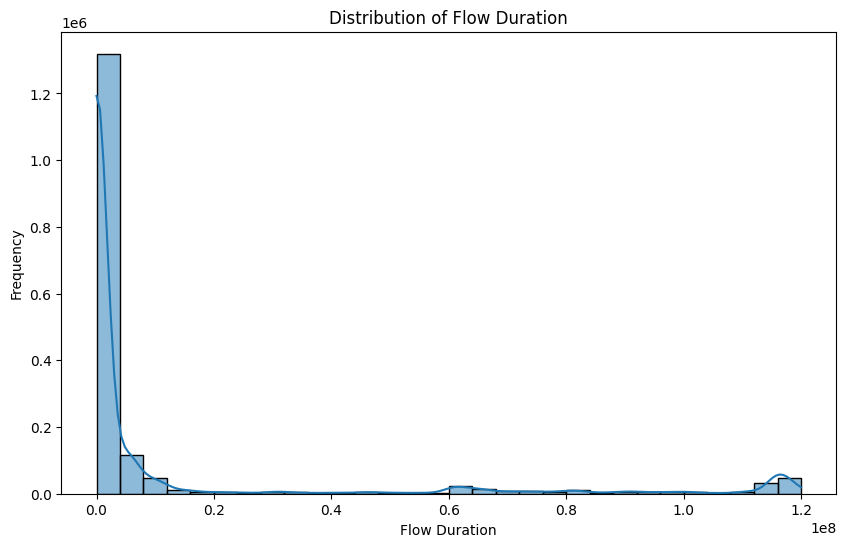

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(Net['Flow Duration'], bins=30, kde=True)
plt.title('Distribution of Flow Duration')
plt.xlabel('Flow Duration')
plt.ylabel('Frequency')
plt.show()

In [22]:
print(Net.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Id

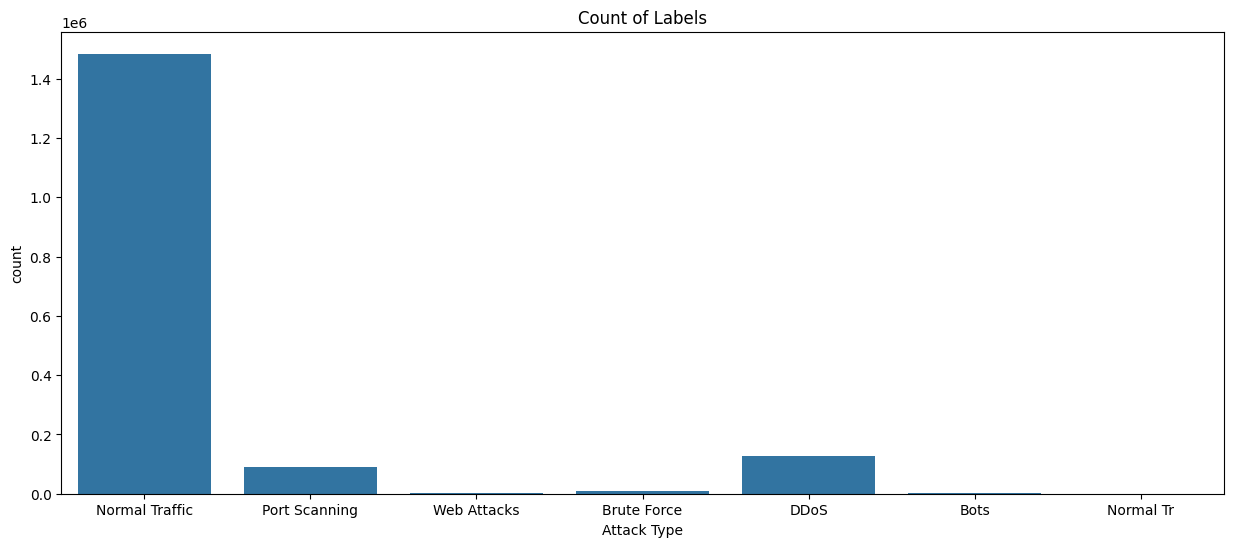

In [23]:
plt.figure(figsize=(15, 6))
sns.countplot(x='Attack Type', data=Net)
plt.title('Count of Labels')
plt.show()


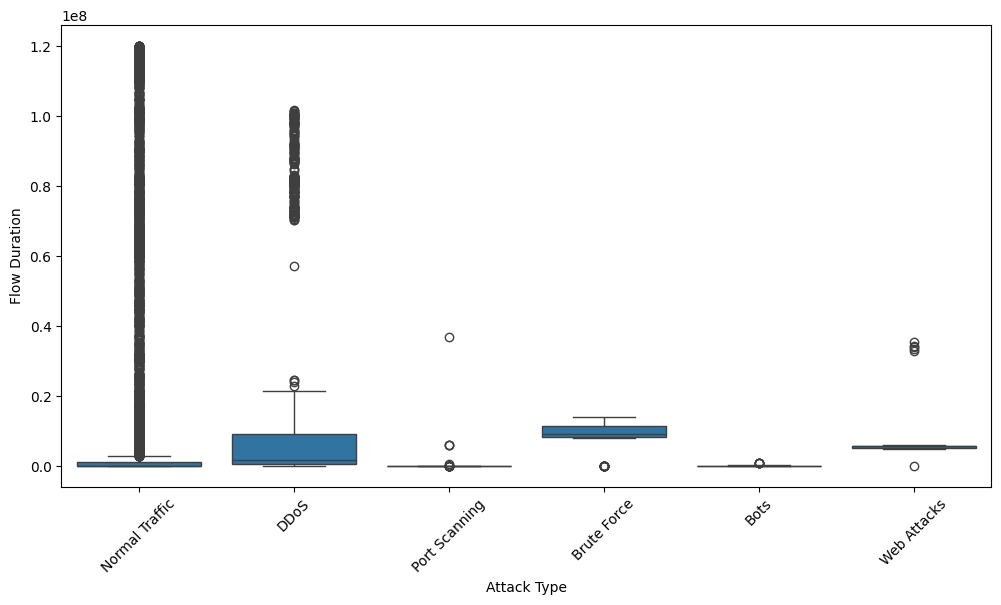

In [24]:
Net_sample = Net.sample(20000, random_state=42)

plt.figure(figsize=(12,6))
sns.boxplot(x='Attack Type', y='Flow Duration', data=Net_sample)
plt.xticks(rotation=45)
plt.show()

# Feature Selection

### LabelEncoder

In [25]:
label_encoder = LabelEncoder()
categorical_columns = ["Attack Type"]

for col in categorical_columns:
    if Net[col].dtype == 'object':
        Net[col] = label_encoder.fit_transform(Net[col].astype(str))

In [26]:
Net.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7595.104640,67.122468,15075.50000,104051.399700,948537,0,1266342,31658.550,159355.2595,996324,2,317671,7387.697674,19636.44809,104616,1,1328,1424,32.376720,34.745748,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,4
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,158.045455,312.675250,7289.936810,64.425518,15706.58333,104861.870100,955790,1,1319353,32983.825,159247.9008,996423,1,363429,8451.837209,21337.26261,104815,1,1328,1424,31.075838,33.349680,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,4
2,22,160,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,12500.000000,160.00000,0.000000,160,160,0,0.000,0.0000,0,0,0,0.000000,0.00000,0,0,32,32,6250.000000,6250.000000,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,290,243,0,32,0.0,0,0,0.0,0,0,4
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,157.952381,319.121427,7182.267884,63.675308,15896.19512,106554.899000,956551,0,1303488,32587.200,160397.0499,997357,1,346851,8459.780488,23962.23892,138295,0,1328,1360,31.454068,32.221240,0,976,111.452381,241.642791,58391.23867,0,1,0,112.795181,2728,29200,243,24,32,0.0,0,0,0.0,0,0,4
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,38961.038960,38.50000,14.849242,49,28,0,0.000,0.0000,0,0,49,49.000000,0.00000,49,49,32,64,12987.012990,25974.025970,0,0,0.000000,0.000000,0.00000,0,0,1,0.000000,0,243,290,0,32,0.0,0,0,0.0,0,0,4


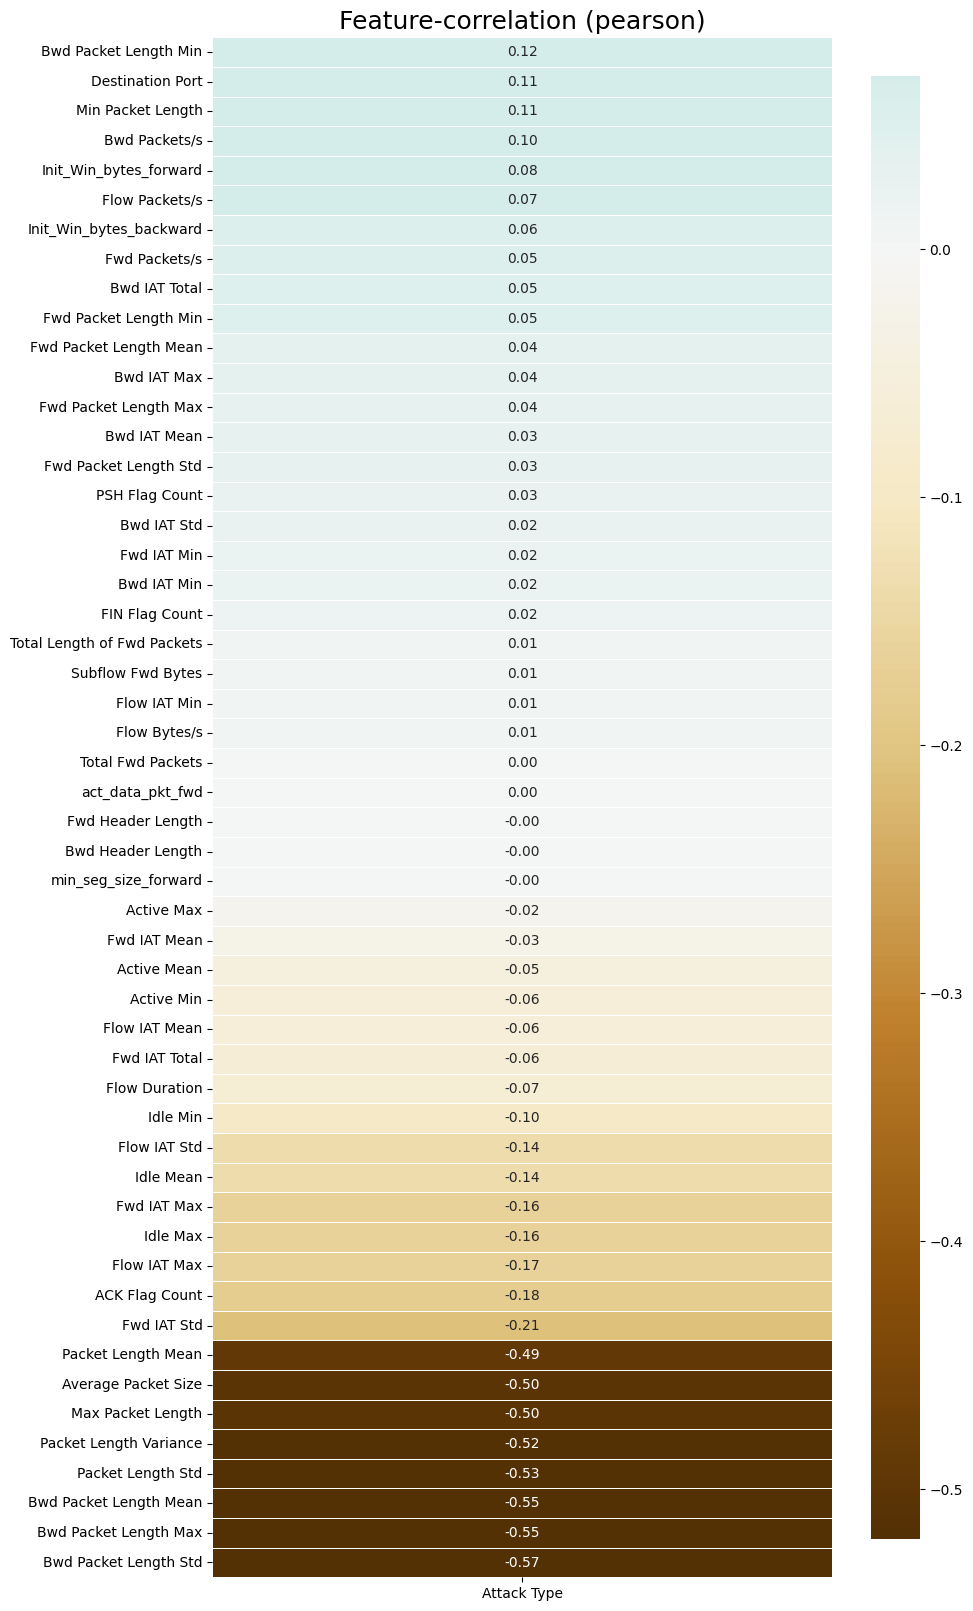

In [27]:
# using coreelation matrix to find the most important features

kl.corr_plot(Net,figsize=(10,20),target='Attack Type')
plt.show()

In [28]:
from sklearn.feature_selection import SelectKBest, f_regression

# Assuming your target variable is in 'label' and your features are all other columns
X = Net.drop(columns=['Attack Type'])
y = Net['Attack Type']  # Assuming this is your target variable

# Apply SelectKBest
selector = SelectKBest(score_func=f_regression, k=15)  # Select top 10 features
X_selected = selector.fit_transform(X, y)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]

print("Selected Features:", selected_features)

Selected Features: Index(['Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Std',
       'Fwd IAT Max', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'ACK Flag Count',
       'Average Packet Size', 'Idle Mean', 'Idle Max'],
      dtype='object')


In [29]:
# Count the number of instances per class
class_counts = Net['Attack Type'].value_counts()

# Display class distribution
print(class_counts)


Attack Type
4    1484401
2     128014
5      90694
1       9150
6       2143
0       1948
3          1
Name: count, dtype: int64


In [30]:
# Specify the classes you want to keep
selected_classes = [6, 7, 8, 9 ,25]  # Modify this list based on your requirement

# Filter the dataset based on the selected classes
selected_class_data = Net[Net['Attack Type'].isin(selected_classes)]

# Save the new dataset with selected classes
selected_class_data.to_csv('selected_classes_dataset.csv', index=False)

print("New dataset created with specific selected classes.")

New dataset created with specific selected classes.


In [31]:
new_tim = pd.read_csv('selected_classes_dataset.csv',low_memory=False)

In [32]:
new_tim

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,80,5185118,7,1022,372,0,146.000000,184.078788,1047,0,331.571429,439.659284,644.729782,2.700035,398855.2308,1372180.710,4963956,4,221162,3.686033e+04,5.614102e+04,141434,4,5185004,8.641673e+05,2.027593e+06,5001548,879,232,232,1.350017,1.350017,0,1047,222.866667,331.323939,1.097756e+05,0,1,0,238.785714,1022,29200,252,3,32,0.0,0,0,0.0,0,0,6
1,80,5057374,10,736,395,0,73.600000,155.683582,4344,0,1411.428571,1639.915430,2099.113097,3.361428,316085.8750,1239255.101,4963124,36,5057374,5.619304e+05,1.650529e+06,4963124,192,56185,9.364167e+03,1.056712e+04,21624,36,328,232,1.977311,1.384118,0,4344,589.777778,1190.454068,1.417181e+06,0,1,0,624.470588,736,29200,243,2,32,0.0,0,0,0.0,0,0,6
2,80,81,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,24691.358020,81.0000,0.000,81,81,0,0.000000e+00,0.000000e+00,0,0,0,0.000000e+00,0.000000e+00,0,0,32,32,12345.679010,12345.679010,0,0,0.000000,0.000000,0.000000e+00,0,0,1,0.000000,0,270,252,0,32,0.0,0,0,0.0,0,0,6
3,80,5271123,7,969,561,0,138.428571,240.502153,1066,0,286.000000,463.646417,455.121233,2.276555,479193.0000,1488840.005,4961916,46,5271123,8.785205e+05,2.003103e+06,4961916,323,270207,6.755175e+04,1.316049e+05,264957,1034,232,168,1.327990,0.948564,0,1066,184.538462,330.066815,1.089441e+05,0,1,0,199.916667,969,29200,244,2,32,0.0,0,0,0.0,0,0,6
4,80,5020638,7,973,565,0,139.000000,241.675402,1066,0,357.500000,502.535903,478.624430,2.190957,502063.8000,1567338.192,4962654,18,5020638,8.367730e+05,2.021330e+06,4962654,18,18708,6.236000e+03,5.195495e+03,11318,934,232,136,1.394245,0.796711,0,1066,200.250000,340.232574,1.157582e+05,0,1,0,218.454545,973,29200,244,2,32,0.0,0,0,0.0,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2138,80,5005388,5,599,599,0,119.800000,267.880944,2021,0,673.666667,1166.824894,523.435945,1.598278,715055.4286,1889547.295,5000145,4,5005388,1.251347e+06,2.499199e+06,5000145,4,4429,2.214500e+03,1.892925e+03,3553,876,168,104,0.998924,0.599354,0,2021,291.111111,678.281919,4.600664e+05,0,1,0,327.500000,599,29200,236,1,32,0.0,0,0,0.0,0,0,6
2139,80,5016759,5,599,599,0,119.800000,267.880944,2701,0,829.800000,1219.555739,946.427763,1.993319,557417.6667,1667490.203,5004049,4,12710,3.177500e+03,5.465625e+03,11356,4,5016632,1.254158e+06,2.500655e+06,5005134,47,168,168,0.996659,0.996659,0,2701,431.636364,877.581708,7.701497e+05,0,1,0,474.800000,599,29200,236,1,32,0.0,0,0,0.0,0,0,6
2140,80,5009163,4,599,599,0,149.750000,299.500000,2021,0,505.250000,1010.500000,523.041474,1.597073,715594.7143,1890923.412,5003805,56,5358,1.786000e+03,2.252041e+03,4381,343,5009082,1.669694e+06,2.888011e+06,5004482,952,136,136,0.798537,0.798537,0,2021,291.111111,678.281919,4.600664e+05,0,1,0,327.500000,599,29200,236,1,32,0.0,0,0,0.0,0,0,6
2141,80,73,1,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,27397.260270,73.0000,0.000,73,73,0,0.000000e+00,0.000000e+00,0,0,0,0.000000e+00,0.000000e+00,0,0,32,32,13698.630140,13698.630140,0,0,0.000000,0.000000,0.000000e+00,0,0,1,0.000000,0

In [33]:
Net = Net[Net['Attack Type'] != 3]

In [34]:
# Features and target
X = Net.drop('Attack Type', axis=1)
y = Net['Attack Type']

In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5]
[0 1 2 3 4 5]


In [38]:
X_train = X_train.values
X_test = X_test.values

In [39]:
clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

In [40]:
clf.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9994785445858945

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.73      0.79       390
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00    296880
           4       1.00      1.00      1.00     18139
           5       0.99      0.98      0.98       428

    accuracy                           1.00    343270
   macro avg       0.98      0.95      0.96    343270
weighted avg       1.00      1.00      1.00    343270



In [42]:
# ==============================
# 1️⃣ Minority Class Extraction
# ==============================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Convert to numpy
X_train_np = np.asarray(X_train)
y_train_np = np.asarray(y_train)
X_test_np = np.asarray(X_test)

# Check class distribution
class_counts = Counter(y_train_np)
print("Class distribution:", class_counts)

# Detect minority class automatically
minority_class = min(class_counts, key=class_counts.get)
print("Minority class:", minority_class)

# Extract minority samples
X_minority = X_train_np[y_train_np == minority_class]
print("Minority samples shape:", X_minority.shape)


# ==============================
# 2️⃣ GAN Model Definitions
# ==============================

latent_dim = 32
output_dim = X_minority.shape[1]

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(output_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# ==============================
# 3️⃣ GAN Training Setup
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

loss_fn = nn.BCELoss()

train_tensor = torch.tensor(X_minority, dtype=torch.float32).to(device)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

epochs = 30


# ==============================
# 4️⃣ Train GAN
# ==============================

for epoch in range(epochs):
    for real_batch in train_loader:

        real_batch = real_batch[0].to(device)
        batch_size = real_batch.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---- Train Discriminator ----
        optimizer_D.zero_grad()

        output_real = D(real_batch)
        loss_real = loss_fn(output_real, real_labels)

        noise = torch.randn(batch_size, latent_dim).to(device)
        fake_data = G(noise)

        output_fake = D(fake_data.detach())
        loss_fake = loss_fn(output_fake, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, latent_dim).to(device)
        fake_data = G(noise)

        output_fake = D(fake_data)
        g_loss = loss_fn(output_fake, real_labels)

        g_loss.backward()
        optimizer_G.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}/{epochs} | D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")


# ==============================
# 5️⃣ Generate Synthetic Samples
# ==============================

num_samples = 4000   # Safe augmentation size

noise = torch.randn(num_samples, latent_dim).to(device)
synthetic_samples = G(noise).detach().cpu().numpy()

synthetic_labels = np.full(num_samples, minority_class)

print("Generated synthetic samples:", synthetic_samples.shape)


# ==============================
# 6️⃣ Augment Training Data
# ==============================

X_train_aug = np.vstack((X_train_np, synthetic_samples))
y_train_aug = np.hstack((y_train_np, synthetic_labels))

print("New training shape:", X_train_aug.shape)


# ==============================
# 7️⃣ Retrain Random Forest
# ==============================

clf_aug = RandomForestClassifier(
    n_estimators=50,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

clf_aug.fit(X_train_aug, y_train_aug)

y_pred_aug = clf_aug.predict(X_test_np)

print("\n===== AFTER GAN AUGMENTATION =====")
print("Accuracy:", accuracy_score(y_test, y_pred_aug))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_aug))

Class distribution: Counter({np.int64(3): 1187521, np.int64(2): 102411, np.int64(4): 72555, np.int64(1): 7320, np.int64(5): 1715, np.int64(0): 1558})
Minority class: 0
Minority samples shape: (1558, 52)
Epoch 0/30 | D_loss: 82.4302 | G_loss: 0.7833
Epoch 5/30 | D_loss: 32.3768 | G_loss: 0.8520
Epoch 10/30 | D_loss: 45.9953 | G_loss: 0.8964
Epoch 15/30 | D_loss: 41.5586 | G_loss: 0.7762
Epoch 20/30 | D_loss: 46.9536 | G_loss: 0.2332
Epoch 25/30 | D_loss: 47.3186 | G_loss: 0.1926
Generated synthetic samples: (4000, 52)
New training shape: (1377080, 52)

===== AFTER GAN AUGMENTATION =====
Accuracy: 0.9994785445858945

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.73      0.79       390
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00    296880
           4       1.00      1.00      1.00     18139
           5       1.00     

In [43]:
# ============================================
# 1️⃣ Imports
# ============================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 2️⃣ Prepare Data (Use SAME dataset as RF/GAN)
# ============================================

# Use your existing Net dataset
X = Net.drop('Attack Type', axis=1)
y = Net['Attack Type']

# Encode labels if needed
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=128,
    shuffle=True
)


# ============================================
# 3️⃣ RBM Definition (Fixed)
# ============================================

class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_visible, n_hidden) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))

    def forward(self, v):
        h_prob = torch.sigmoid(torch.matmul(v, self.W) + self.h_bias)
        return h_prob


# ============================================
# 4️⃣ DBN Definition
# ============================================

class DBN(nn.Module):
    def __init__(self, input_dim, hidden_layers, num_classes):
        super(DBN, self).__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# ============================================
# 5️⃣ Initialize DBN
# ============================================

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))

dbn = DBN(
    input_dim=input_dim,
    hidden_layers=[256, 128, 64],
    num_classes=num_classes
).to(device)


# ============================================
# 6️⃣ Train DBN Classifier
# ============================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dbn.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    dbn.train()
    total_loss = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = dbn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")


# ============================================
# 7️⃣ Evaluate DBN
# ============================================

dbn.eval()
with torch.no_grad():
    outputs = dbn(X_test_tensor)
    _, predicted = torch.max(outputs, 1)

    accuracy = accuracy_score(
        y_test_tensor.cpu(),
        predicted.cpu()
    )

    print("\n===== DBN RESULTS =====")
    print("Accuracy:", accuracy)
    print("\nClassification Report:\n")
    print(classification_report(
        y_test_tensor.cpu(),
        predicted.cpu()
    ))

Epoch 1/10, Loss: 270.1861
Epoch 2/10, Loss: 141.7784
Epoch 3/10, Loss: 124.4488
Epoch 4/10, Loss: 116.4964
Epoch 5/10, Loss: 110.8440
Epoch 6/10, Loss: 103.6228
Epoch 7/10, Loss: 101.9262
Epoch 8/10, Loss: 101.9304
Epoch 9/10, Loss: 95.2583
Epoch 10/10, Loss: 93.5724

===== DBN RESULTS =====
Accuracy: 0.9975558598188016

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.34      0.50       390
           1       0.99      0.97      0.98      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00    296880
           4       1.00      1.00      1.00     18139
           5       0.94      0.07      0.13       428

    accuracy                           1.00    343270
   macro avg       0.98      0.73      0.77    343270
weighted avg       1.00      1.00      1.00    343270



In [44]:
import numpy as np
from collections import Counter

# Convert to numpy
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

# Find minority class
class_counts = Counter(y_train_np)
minority_class = min(class_counts, key=class_counts.get)

print("Class distribution:", class_counts)
print("Minority class:", minority_class)

# Extract minority samples
X_minority = X_train_np[y_train_np == minority_class]

print("Minority shape:", X_minority.shape)

Class distribution: Counter({np.int64(3): 1187521, np.int64(2): 102411, np.int64(4): 72555, np.int64(1): 7320, np.int64(5): 1715, np.int64(0): 1558})
Minority class: 0
Minority shape: (1558, 52)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler_min = StandardScaler()
X_minority_scaled = scaler_min.fit_transform(X_minority)

In [46]:
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_min_tensor = torch.tensor(X_minority_scaled, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_min_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [47]:
import torch.nn as nn
import torch.optim as optim

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=16):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return self.fc4(h)   # NO sigmoid

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [48]:
def vae_loss(recon_x, x, mu, logvar):
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

In [49]:
input_dim = X_minority_scaled.shape[1]
vae = VAE(input_dim=input_dim).to(device)

optimizer = optim.Adam(vae.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    total_loss = 0

    for batch in train_loader:
        data = batch[0]

        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(data)
        loss = vae_loss(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.2f}")

Epoch 1/30, Loss: 79255.63
Epoch 2/30, Loss: 58369.77
Epoch 3/30, Loss: 43947.82
Epoch 4/30, Loss: 39583.08
Epoch 5/30, Loss: 35357.52
Epoch 6/30, Loss: 91838.26
Epoch 7/30, Loss: 30882.26
Epoch 8/30, Loss: 39977.69
Epoch 9/30, Loss: 43253.74
Epoch 10/30, Loss: 24182.87
Epoch 11/30, Loss: 21188.18
Epoch 12/30, Loss: 19739.34
Epoch 13/30, Loss: 19269.33
Epoch 14/30, Loss: 18362.73
Epoch 15/30, Loss: 17971.19
Epoch 16/30, Loss: 17416.87
Epoch 17/30, Loss: 17239.76
Epoch 18/30, Loss: 17252.21
Epoch 19/30, Loss: 17146.77
Epoch 20/30, Loss: 36570.49
Epoch 21/30, Loss: 17857.62
Epoch 22/30, Loss: 17616.25
Epoch 23/30, Loss: 1270736.79
Epoch 24/30, Loss: 39309.32
Epoch 25/30, Loss: 365709.65
Epoch 26/30, Loss: 32325.73
Epoch 27/30, Loss: 28668.72
Epoch 28/30, Loss: 25805.92
Epoch 29/30, Loss: 22022.91
Epoch 30/30, Loss: 19711.02


In [50]:
num_synthetic = 4000  # adjust as needed

with torch.no_grad():
    z = torch.randn(num_synthetic, 16).to(device)
    synthetic_scaled = vae.decode(z).cpu().numpy()

# Reverse scaling
synthetic_samples = scaler_min.inverse_transform(synthetic_scaled)

print("Generated synthetic samples:", synthetic_samples.shape)

Generated synthetic samples: (4000, 52)


In [51]:
X_train_aug = np.vstack([X_train_np, synthetic_samples])
y_train_aug = np.hstack([y_train_np, 
                         np.full(num_synthetic, minority_class)])

print("New training shape:", X_train_aug.shape)

New training shape: (1377080, 52)


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

clf_vae = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf_vae.fit(X_train_aug, y_train_aug)

y_pred_vae = clf_vae.predict(X_test)

print("\n===== AFTER VAE AUGMENTATION =====")
print("Accuracy:", accuracy_score(y_test, y_pred_vae))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_vae))


===== AFTER VAE AUGMENTATION =====
Accuracy: 0.9994785445858945

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.72      0.79       390
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00    296880
           4       1.00      1.00      1.00     18139
           5       0.99      0.97      0.98       428

    accuracy                           1.00    343270
   macro avg       0.98      0.95      0.96    343270
weighted avg       1.00      1.00      1.00    343270

